# Fase 1 — Análisis Exploratorio de Datos (EDA)

**Objetivo de esta fase:** conocer los datos antes de tocarlos. No construimos ningún modelo todavía;
solo respondemos preguntas como: *¿qué variables tenemos?, ¿cuáles tienen huecos (nulos)?,
¿cuáles parecen estar relacionadas con sobrevivir?*

¿Por qué hacerlo primero? Porque **cada decisión de las fases siguientes (limpieza, creación de
variables, elección de modelo) debe estar justificada por algo que hayamos visto aquí**, no por
intuición. Un EDA bien hecho evita errores como imputar mal los nulos o descartar una variable útil.

> 💡 **Cómo leer este notebook:** cada bloque tiene una celda de texto (como esta) que explica *qué*
> vamos a hacer y *por qué*, seguida de una celda de código que lo hace, y después la interpretación
> de lo que se ve.

## 1 · Importar librerías

Cada librería tiene un papel concreto:

| Librería | Para qué la usamos |
|---|---|
| `pandas` | Manipular tablas de datos (los famosos *DataFrames*). Es la herramienta central. |
| `numpy` | Operaciones numéricas de bajo nivel (pandas la usa por debajo). |
| `matplotlib` | Dibujar gráficos. Es la librería base de visualización en Python. |
| `seaborn` | Capa encima de matplotlib con gráficos estadísticos más cómodos (la usaremos para el mapa de calor). |

La línea `%matplotlib inline` es un *comando mágico* de Jupyter: hace que los gráficos se dibujen
dentro del notebook en lugar de abrirse en una ventana aparte.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas", pd.__version__, "| numpy", np.__version__,
      "| matplotlib", mpl.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | numpy 2.1.1 | matplotlib 3.10.0 | seaborn 0.13.2


### 1.1 · Configurar el estilo de los gráficos

Antes de dibujar nada, fijamos unas reglas de estilo **una sola vez** para todo el notebook.
Esto no es solo estética, es legibilidad:

- **Colores fijos por significado**: *no sobrevivió* será siempre **azul** y *sobrevivió* siempre
  **verde agua**, en todos los gráficos. Si el color cambiara de un gráfico a otro, el lector tendría
  que re-aprender la leyenda cada vez. (La paleta elegida está validada para daltonismo.)
- **Rejilla discreta y sin bordes superiores/derechos**: la rejilla ayuda a leer valores pero no debe
  competir con los datos.
- **Etiquetas directas sobre las barras**: escribimos el valor encima de cada barra para no obligar
  al lector a estimarlo contra el eje.

`mpl.rcParams` es el diccionario de configuración global de matplotlib: lo que fijemos aquí aplica a
todos los gráficos siguientes.

In [2]:
# --- Paleta (validada para accesibilidad/daltonismo) ---
C_NO  = "#2a78d6"   # azul  -> No sobrevivio (0)
C_SI  = "#1baf7a"   # aqua  -> Sobrevivio (1)
C_A   = "#4a3aa7"   # violeta -> primer nivel de otras categorias (p.ej. mujer)
C_B   = "#eb6834"   # naranja -> segundo nivel (p.ej. hombre)
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 1,
    "axes.spines.top": False, "axes.spines.right": False,   # sin bordes arriba/derecha
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True,                                  # rejilla DETRAS de las barras
    "text.color": INK, "axes.labelcolor": SECONDARY,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "Segoe UI", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "figure.figsize": (7, 4),
})

def tasa_barras(serie, titulo, color=C_NO, xlabel=None):
    """Dibuja una serie de tasas (0-1) como barras con etiqueta directa en %."""
    ax = serie.plot(kind="bar", color=color, width=0.6, rot=0)
    ax.bar_label(ax.containers[0], fmt=lambda v: f"{v:.0%}", padding=3, color=SECONDARY)
    ax.set_title(titulo); ax.set_xlabel(xlabel or serie.index.name or ""); ax.set_ylabel("tasa de supervivencia")
    ax.set_ylim(0, 1.05); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.grid(axis="x", visible=False)
    return ax

## 2 · Cargar los datos

`pd.read_csv()` lee un archivo CSV (texto separado por comas) y lo convierte en un **DataFrame**:
una tabla con filas y columnas, parecida a una hoja de cálculo, donde cada columna tiene un tipo de
dato (número, texto…).

Cargamos los dos conjuntos:

- **`train`** (891 pasajeros): incluye la columna `Survived` (la respuesta). Con él exploramos y entrenaremos.
- **`test`** (418 pasajeros): SIN `Survived`. Es el examen — nuestro modelo tendrá que predecirlo.

La ruta empieza por `../` porque este notebook vive en `notebooks/` y los datos en `data/`
(un nivel más arriba).

`.shape` devuelve `(filas, columnas)` — la comprobación más rápida de que la carga fue bien.

In [3]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

print("train:", train.shape, "->", train.shape[0], "pasajeros y", train.shape[1], "columnas")
print("test :", test.shape,  "-> sin la columna Survived, por eso tiene una menos")

train: (891, 12) -> 891 pasajeros y 12 columnas
test : (418, 11) -> sin la columna Survived, por eso tiene una menos


## 3 · Primer vistazo a la tabla

`train.head(10)` muestra las 10 primeras filas. Sirve para ver la *pinta* real de los datos:
formatos, valores raros, huecos (`NaN` = *Not a Number*, así representa pandas un valor ausente).

Diccionario de columnas:

| Columna | Qué es | Detalle |
|---|---|---|
| `PassengerId` | Identificador único | No aporta información — es un número de fila. |
| `Survived` | **Objetivo (target)** | 1 = sobrevivió, 0 = no. Es lo que queremos predecir. |
| `Pclass` | Clase del billete | 1ª, 2ª o 3ª. Proxy de nivel socioeconómico. |
| `Name` | Nombre completo | Fíjate: contiene el **título** (Mr., Mrs., Miss., Master…) — lo explotaremos. |
| `Sex` | Sexo | `male` / `female`. |
| `Age` | Edad en años | Fraccional si < 1 año; `xx.5` indica edad estimada. Tiene muchos nulos. |
| `SibSp` | Hermanos/cónyuge a bordo | *Siblings + Spouse*. |
| `Parch` | Padres/hijos a bordo | *Parents + Children*. |
| `Ticket` | Nº de billete | Ojo: hay billetes **compartidos** por grupos. |
| `Fare` | Precio del billete | ¡Es el precio del billete completo, no por persona! |
| `Cabin` | Camarote | Casi siempre vacío; la letra inicial es la cubierta del barco. |
| `Embarked` | Puerto de embarque | C = Cherburgo, Q = Queenstown, S = Southampton. |

In [4]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### 3.1 · Tipos de datos

`.info()` resume, por columna: cuántos valores **no nulos** tiene y su **tipo** (`dtype`):

- `int64` / `float64` → numéricas. Ojo: `Age` es `float64` en parte *porque tiene nulos*
  (pandas no puede representar `NaN` en una columna de enteros clásica).
- `object` → texto (cadenas). Los modelos no entienden texto: en la Fase 3 habrá que
  **codificar** estas columnas como números.

También fíjate en que `Pclass` es numérica (1, 2, 3) pero en realidad es una **categoría ordenada**,
no una cantidad: un 3 no es "tres veces" un 1.

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


### 3.2 · Estadísticos básicos

`.describe()` calcula, para cada columna numérica:

- **count**: cuántos valores no nulos hay (¡detecta nulos!).
- **mean** (media) y **std** (desviación típica: cuánto se dispersan los valores alrededor de la media).
- **min / max**: extremos — útiles para detectar valores imposibles.
- **25% / 50% / 75%**: percentiles. El 50% es la **mediana**: el valor que deja la mitad de los datos
  a cada lado. Comparar media vs mediana revela **asimetría**: si la media es mucho mayor que la
  mediana, hay pocos valores enormes tirando de la media hacia arriba.

(`.T` solo transpone la tabla para leerla mejor.)

In [6]:
train.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.00,257.35,1.00,223.50,446.00,668.5,891.00
Survived,891.0,0.38,0.49,0.00,0.00,0.00,1.0,1.00
Pclass,891.0,2.31,0.84,1.00,2.00,3.00,3.0,3.00
Age,714.0,29.70,14.53,0.42,20.12,28.00,38.0,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.0,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.0,6.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.0,512.33


**Lectura de esta tabla** (esto es lo importante del EDA — no los números, sino qué nos dicen):

- `Survived` — media **0.38**: como es una columna de 0s y 1s, la media es directamente la
  proporción de supervivientes → **38.4%** sobrevivió, 61.6% no.
- `Age` — count = **714** de 891 → faltan 177 edades. Media ~29.7 años, desde bebés (0.42 = 5 meses)
  hasta 80 años.
- `Fare` — media **32.2** pero mediana **14.45**: fuerte asimetría. El máximo es 512£ (¡un billete
  carísimo!) mientras el 75% pagó menos de 31£. Pocos ricos tiran de la media hacia arriba.
- `SibSp`/`Parch` — medianas 0: **la mayoría viajaba sin familia**.

Para las columnas de texto usamos `describe(include="object")`: `unique` = nº de valores distintos,
`top` = el más frecuente, `freq` = cuántas veces aparece.

In [7]:
train.describe(include="object").T

,count,unique,top,freq
Name,891,891,"Dooley, Mr. Patrick",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,G6,4
Embarked,889,3,S,644


Dos detalles jugosos aquí:

- `Ticket`: solo **681 valores únicos** para 891 pasajeros → hay billetes repetidos, es decir,
  **grupos que viajaban con el mismo billete** (familias, criados…). Esto confirma que `Fare` es por
  billete, no por persona.
- `Cabin`: solo 204 registros y 147 únicos. Demasiado vacío para usarlo tal cual.

## 4 · Auditoría de valores nulos

Un **nulo** (`NaN`) es un dato que no se registró. Importan por dos razones:

1. La mayoría de modelos de sklearn **no aceptan nulos** — hay que decidir qué hacer con ellos.
2. *Por qué* falta un dato puede ser informativo en sí mismo (p. ej., tener camarote registrado
   o no lo es — lo veremos en la sección 12).

Código: `isna()` devuelve una tabla de True/False (¿es nulo?), y `.sum()` cuenta los True por
columna (en Python, True vale 1). Lo calculamos para train y test **por separado** porque las
decisiones de limpieza deben cubrir ambos.

In [8]:
nulos = pd.DataFrame({
    "train_nulos": train.isna().sum(),
    "train_%": (train.isna().mean() * 100).round(1),
    "test_nulos": test.isna().sum().reindex(train.columns),
    "test_%": (test.isna().mean() * 100).reindex(train.columns).round(1),
})
nulos[nulos[["train_nulos", "test_nulos"]].sum(axis=1) > 0]

,train_nulos,train_%,test_nulos,test_%
Age,177,19.9,86.0,20.6
Fare,0,0.0,1.0,0.2
Cabin,687,77.1,327.0,78.2
Embarked,2,0.2,0.0,0.0


**Conclusiones para la Fase 2 (limpieza):**

| Columna | Nulos | Decisión prevista |
|---|---|---|
| `Age` | 177 train (19.9%) + 86 test | Demasiados para tirar las filas y demasiado importante para descartarla → **imputar** (rellenar) con la mediana *por grupo* (título + clase), no la global. |
| `Cabin` | 687 train (77.1%) + 327 test | Imposible de imputar con fiabilidad → derivar `HasCabin` (¿tiene camarote registrado?) y descartar el resto. |
| `Embarked` | 2 train | Solo 2 casos → imputar con la moda (el valor más frecuente, `S`). |
| `Fare` | 1 test | Un solo caso → mediana de su clase. |

> ⚠️ Regla que respetaremos siempre: los valores de imputación (medianas, modas) se calculan
> **solo con train**. Si usáramos el test estaríamos filtrando información del examen al estudio
> (*data leakage*).

## 5 · La variable objetivo: `Survived`

Antes de mirar ninguna otra variable, hay que entender el **target**:

- **¿Está balanceado?** Si una clase fuera rarísima (p. ej. 1% de supervivientes), la accuracy sería
  engañosa y necesitaríamos técnicas especiales. Con 38% / 62% hay desbalanceo *moderado*: accuracy
  sigue siendo una métrica razonable.
- **Nos da el primer baseline "tonto":** un "modelo" que predijera *nadie sobrevive* acertaría el
  **61.6%** de las veces. Ese es el suelo absoluto: cualquier modelo que entrenemos debe superarlo
  con claridad (y también al baseline de género, ~76.6%, que veremos ahora).

`value_counts()` cuenta cuántas filas hay de cada valor; con `normalize=True` da proporciones.

Survived
No sobrevivio    549
Sobrevivio       342
Name: count, dtype: int64 

Survived
No sobrevivio (%)    61.6
Sobrevivio (%)       38.4
Name: proportion, dtype: float64


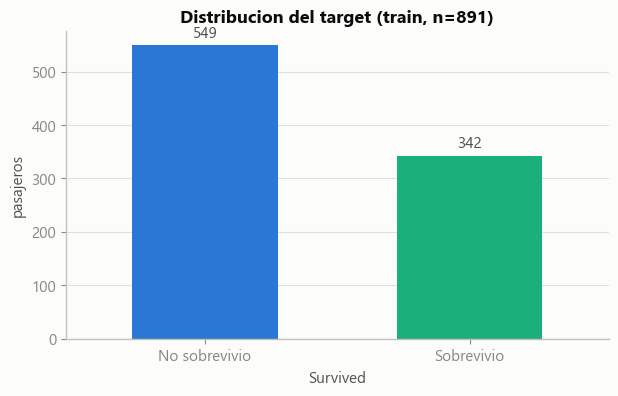

In [9]:
conteo = train["Survived"].value_counts().rename({0: "No sobrevivio", 1: "Sobrevivio"})
print(conteo, "\n")
print((train["Survived"].value_counts(normalize=True) * 100).round(1).rename({0: "No sobrevivio (%)", 1: "Sobrevivio (%)"}))

ax = conteo.plot(kind="bar", color=[C_NO, C_SI], width=0.55, rot=0)
ax.bar_label(ax.containers[0], padding=3, color=SECONDARY)
ax.set_title("Distribucion del target (train, n=891)")
ax.set_ylabel("pasajeros"); ax.grid(axis="x", visible=False)
plt.show()

## 6 · `Sex` — la señal más fuerte

Pregunta: *¿sobrevivieron más las mujeres que los hombres?* (Contexto histórico: el protocolo
"mujeres y niños primero" en los botes salvavidas.)

Herramienta nueva: **`groupby`**. `train.groupby("Sex")["Survived"].mean()` significa:
*divide las filas en grupos según `Sex`, y para cada grupo calcula la media de `Survived`*.
Como `Survived` es 0/1, esa media es directamente la **tasa de supervivencia del grupo**.
Este patrón (agrupar → tasa) lo repetiremos con todas las variables categóricas.

         pasajeros  tasa_supervivencia
Sex                                   
Hombres        577               0.189
Mujeres        314               0.742


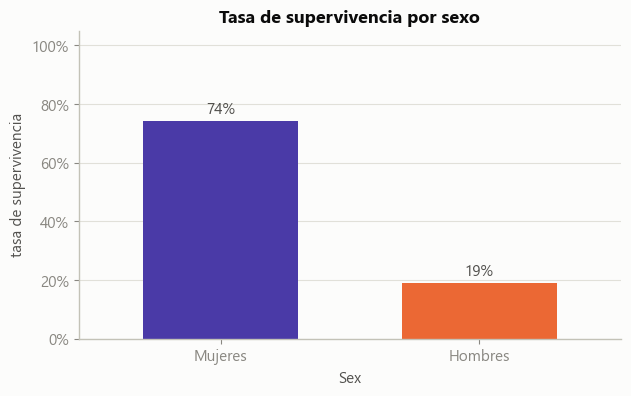

In [10]:
tasa_sexo = train.groupby("Sex")["Survived"].mean().rename({"female": "Mujeres", "male": "Hombres"})
n_sexo = train["Sex"].value_counts().rename({"female": "Mujeres", "male": "Hombres"})
print(pd.DataFrame({"pasajeros": n_sexo, "tasa_supervivencia": tasa_sexo.round(3)}))

tasa_barras(tasa_sexo, "Tasa de supervivencia por sexo", color=[C_A, C_B])
plt.show()

**Interpretación:** la diferencia es enorme — **~74% de las mujeres** sobrevivió frente a
**~19% de los hombres**. `Sex` es, con diferencia, la variable individual más predictiva.

Esto explica el archivo `gender_submission.csv` de Kaggle: predecir simplemente
*mujer → sobrevive, hombre → no* logra **0.7655** en el leaderboard. Ese es nuestro segundo baseline:
todo modelo serio debe superarlo. Y nos dice algo más: el margen de mejora está en encontrar
**qué hombres sobrevivieron y qué mujeres no** — ahí es donde las demás variables aportan.

## 7 · `Pclass` — la clase social

Segunda hipótesis clásica: *los pasajeros de 1ª clase tuvieron ventaja* (camarotes más cerca de
cubierta, acceso más rápido a los botes, trato preferente).

Además de la tasa por clase, cruzaremos **clase × sexo** con `pd.pivot_table`. ¿Por qué? Porque dos
variables pueden **interactuar**: el efecto de la clase podría ser distinto en hombres y en mujeres.
Un buen modelo necesita capturar esas interacciones.

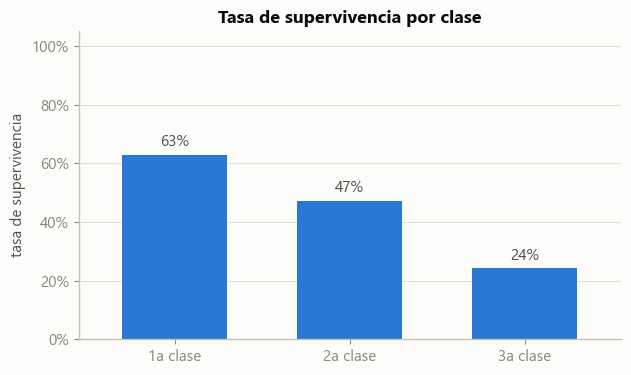

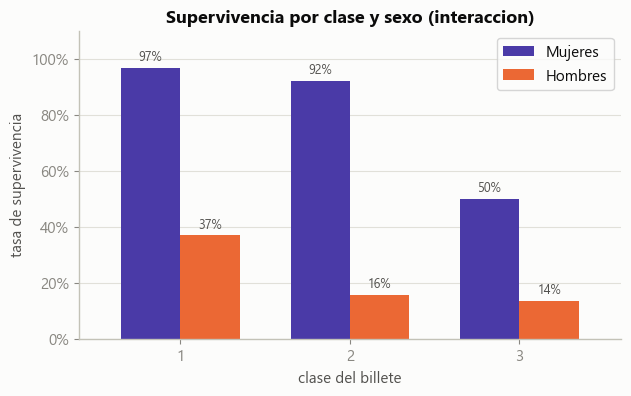

In [11]:
tasa_clase = train.groupby("Pclass")["Survived"].mean()
tasa_clase.index = ["1a clase", "2a clase", "3a clase"]
tasa_barras(tasa_clase, "Tasa de supervivencia por clase")
plt.show()

pivote = pd.pivot_table(train, values="Survived", index="Pclass", columns="Sex", aggfunc="mean")
pivote.columns = ["Mujeres", "Hombres"]
ax = pivote.plot(kind="bar", color=[C_A, C_B], width=0.7, rot=0)
for cont in ax.containers:
    ax.bar_label(cont, fmt=lambda v: f"{v:.0%}", padding=3, color=SECONDARY, fontsize=9)
ax.set_title("Supervivencia por clase y sexo (interaccion)")
ax.set_xlabel("clase del billete"); ax.set_ylabel("tasa de supervivencia")
ax.set_ylim(0, 1.1); ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.grid(axis="x", visible=False); ax.legend(title="")
plt.show()

**Interpretación:**

- El gradiente por clase es claro: **1ª ≈ 63%, 2ª ≈ 47%, 3ª ≈ 24%**.
- Pero el gráfico de interacción es el revelador: las **mujeres de 1ª y 2ª sobrevivieron casi todas
  (97% y 92%)**, mientras que las de 3ª cayeron al ~50%. En hombres, solo los de 1ª (37%) se
  despegan del suelo (~16-14%).
- Traducción para el modelo: donde de verdad hay incertidumbre (y por tanto margen de acierto) es en
  **mujeres de 3ª** y **hombres de 1ª**. Las demás casillas están casi decididas.

## 8 · `Age` — ¿y los niños primero?

Con una variable **continua** como la edad ya no vale agrupar por valor exacto; usamos:

1. **Histogramas superpuestos**: dibujamos la distribución de edades de los que sobrevivieron y de
   los que no. Donde una distribución "sobresale" sobre la otra hay señal.
2. **Bandas de edad** con `pd.cut`: troceamos la edad en intervalos y calculamos la tasa por banda
   (el mismo patrón groupby de antes).

Nota: aquí solo usamos las 714 filas con edad conocida — los 177 nulos quedan fuera de estos gráficos.

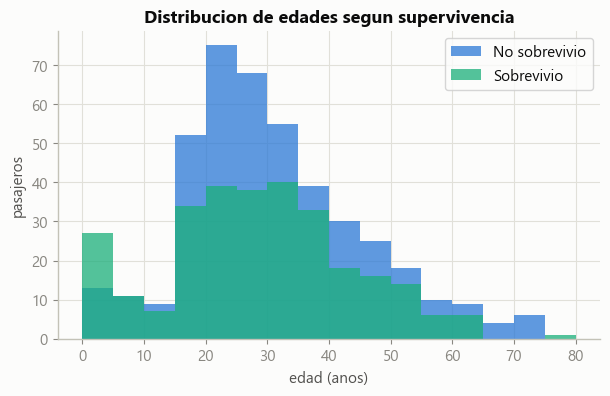

          pasajeros  tasa_supervivencia
Age                                    
(0, 10]          64               0.594
(10, 18]         75               0.427
(18, 30]        270               0.356
(30, 40]        155               0.445
(40, 50]         86               0.384
(50, 60]         42               0.405
(60, 80]         22               0.227


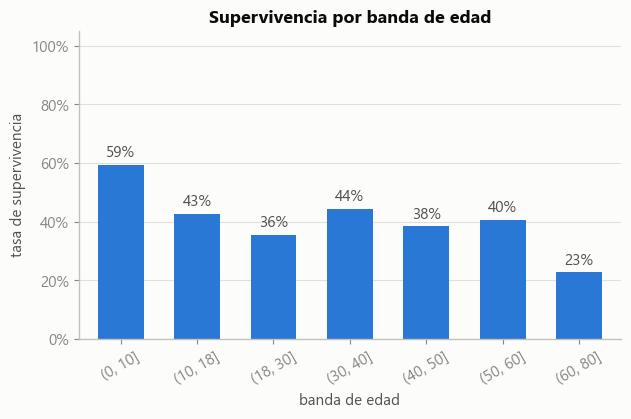

In [12]:
fig, ax = plt.subplots()
bins = np.arange(0, 85, 5)          # cajones de 5 anos: 0-5, 5-10, ...
ax.hist(train.loc[train.Survived == 0, "Age"].dropna(), bins=bins, color=C_NO, alpha=0.75, label="No sobrevivio")
ax.hist(train.loc[train.Survived == 1, "Age"].dropna(), bins=bins, color=C_SI, alpha=0.75, label="Sobrevivio")
ax.set_title("Distribucion de edades segun supervivencia")
ax.set_xlabel("edad (anos)"); ax.set_ylabel("pasajeros"); ax.legend()
plt.show()

bandas = pd.cut(train["Age"], bins=[0, 10, 18, 30, 40, 50, 60, 80])
tabla_edad = train.groupby(bandas, observed=True)["Survived"].agg(["count", "mean"]).round(3)
tabla_edad.columns = ["pasajeros", "tasa_supervivencia"]
print(tabla_edad)

tasa_barras(tabla_edad["tasa_supervivencia"], "Supervivencia por banda de edad", xlabel="banda de edad")
plt.xticks(rotation=30)
plt.show()

**Interpretación:**

- Los **niños de 0-10 años** son la única banda claramente por encima de la media (~59% vs 38%):
  "mujeres **y niños** primero" se cumple.
- Entre 18 y 60 la edad apenas discrimina (todas las bandas rondan el 35-40%).
- En el histograma se ve el pico azul de hombres jóvenes (20-35) que no sobrevivieron.
- Decisiones que motiva esto:
  - La edad importa sobre todo como **"¿es niño?"** → en la Fase 3, el título `Master` (niño varón)
    capturará esto incluso donde `Age` es nulo.
  - Al imputar los 177 nulos hay que hacerlo con cuidado (por título y clase): imputar a todos la
    mediana global (28) mancharía justo la señal de los niños.

## 9 · `Fare` — el precio del billete

Ya vimos que `Fare` es muy **asimétrica** (media 32 vs mediana 14). Para variables así, un histograma
lineal amontona todo a la izquierda; aun así lo mostramos para que veas el problema, y luego usamos
**cuartiles** (`pd.qcut`: corta en 4 grupos con el *mismo número de pasajeros* cada uno) para medir
la relación con la supervivencia sin que los valores extremos dominen.

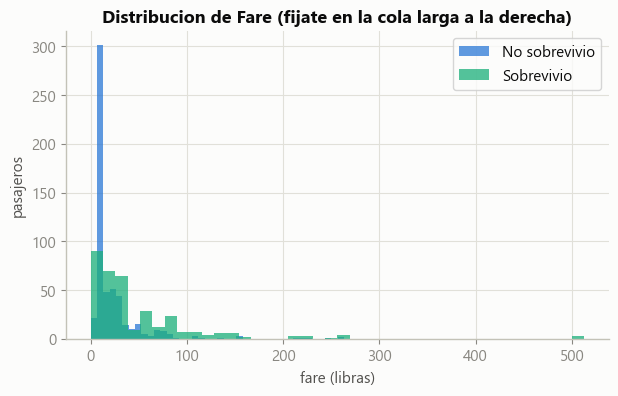

             pasajeros  tasa_supervivencia
Fare                                      
Q1 (barato)        223               0.197
Q2                 224               0.304
Q3                 222               0.455
Q4 (caro)          222               0.581


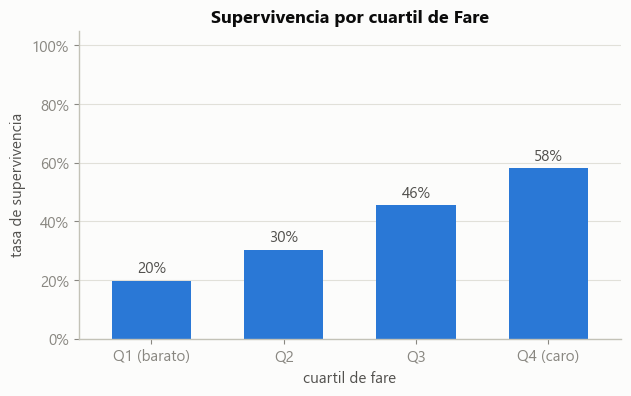

In [13]:
fig, ax = plt.subplots()
ax.hist(train.loc[train.Survived == 0, "Fare"], bins=40, color=C_NO, alpha=0.75, label="No sobrevivio")
ax.hist(train.loc[train.Survived == 1, "Fare"], bins=40, color=C_SI, alpha=0.75, label="Sobrevivio")
ax.set_title("Distribucion de Fare (fijate en la cola larga a la derecha)")
ax.set_xlabel("fare (libras)"); ax.set_ylabel("pasajeros"); ax.legend()
plt.show()

cuartiles = pd.qcut(train["Fare"], q=4, labels=["Q1 (barato)", "Q2", "Q3", "Q4 (caro)"])
tabla_fare = train.groupby(cuartiles, observed=True)["Survived"].agg(["count", "mean"]).round(3)
tabla_fare.columns = ["pasajeros", "tasa_supervivencia"]
print(tabla_fare)

tasa_barras(tabla_fare["tasa_supervivencia"], "Supervivencia por cuartil de Fare", xlabel="cuartil de fare")
plt.show()

**Interpretación:**

- Relación monótona clara: cuanto más caro el billete, más supervivencia (**Q1 ≈ 20% → Q4 ≈ 58%**).
- Pero cuidado: `Fare` está muy **correlacionada con `Pclass`** (los billetes de 1ª son caros).
  Parte de esta señal es la misma que ya vimos en la sección 7 — no son dos pruebas independientes.
- Recordatorio para la Fase 3: `Fare` es el precio **por billete**, y hay billetes de grupo →
  crearemos `FarePerPerson` (fare ÷ tamaño del grupo del ticket), que refleja mejor lo que pagó
  cada persona.

## 10 · `Embarked` — puerto de embarque

A primera vista no debería importar dónde subiste al barco… pero midámoslo. Y aquí aprenderemos un
concepto clave: la **confusión** (*confounding*). Si los pasajeros de Cherburgo sobreviven más,
¿es por el puerto en sí, o porque desde Cherburgo embarcó más gente de 1ª clase? Para saberlo,
miramos también la **composición de clases de cada puerto** (`pd.crosstab` con `normalize="index"`:
tabla cruzada en proporciones por fila).

             pasajeros  tasa_supervivencia
Embarked                                  
Cherburgo          168               0.554
Queenstown          77               0.390
Southampton        644               0.337 

Composicion de clases por puerto:
               % 1a   % 2a   % 3a
Cherburgo    0.506  0.101  0.393
Queenstown   0.026  0.039  0.935
Southampton  0.197  0.255  0.548


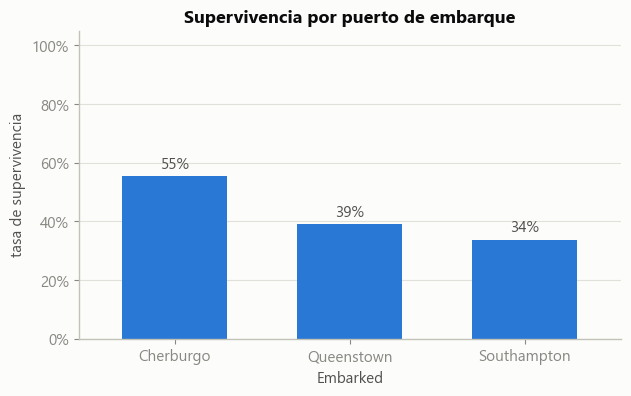

In [14]:
tasa_puerto = train.groupby("Embarked")["Survived"].mean().rename(
    {"C": "Cherburgo", "Q": "Queenstown", "S": "Southampton"})
n_puerto = train["Embarked"].value_counts().rename(
    {"C": "Cherburgo", "Q": "Queenstown", "S": "Southampton"})
print(pd.DataFrame({"pasajeros": n_puerto, "tasa_supervivencia": tasa_puerto.round(3)}), "\n")

composicion = pd.crosstab(train["Embarked"], train["Pclass"], normalize="index").round(3)
composicion.index = ["Cherburgo", "Queenstown", "Southampton"]
composicion.columns = ["% 1a", "% 2a", "% 3a"]
print("Composicion de clases por puerto:\n", composicion)

tasa_barras(tasa_puerto, "Supervivencia por puerto de embarque")
plt.show()

**Interpretación:**

- Cherburgo ≈ **55%** > Queenstown ≈ 39% > Southampton ≈ 34%.
- Pero mira la composición: **el 51% de los embarcados en Cherburgo iban en 1ª clase**, frente al
  ~13% en Queenstown y ~20% en Southampton. La ventaja de Cherburgo es, en buena parte, un reflejo
  de la clase — el ejemplo perfecto de variable *confundida*.
- Decisión: la mantendremos como feature (los modelos de árboles pueden separar el efecto), pero sin
  esperar gran cosa de ella. Sus 2 nulos → moda (`S`).

## 11 · `SibSp` + `Parch` — la familia a bordo

Por separado, estas dos columnas son poco expresivas. Pero podemos **combinarlas** en una variable
nueva (¡nuestro primer *feature engineering*!, aunque de momento solo para explorar):

```
FamilySize = SibSp + Parch + 1      (el +1 es el propio pasajero)
IsAlone    = ¿FamilySize == 1?
```

Hipótesis: viajar solo dificulta sobrevivir (nadie te avisa/ayuda), y las familias muy grandes
también (esperarse unos a otros, niños pequeños que coordinar).

            pasajeros  tasa_supervivencia
FamilySize                               
1                 537               0.304
2                 161               0.553
3                 102               0.578
4                  29               0.724
5                  15               0.200
6                  22               0.136
7                  12               0.333
8                   6               0.000
11                  7               0.000


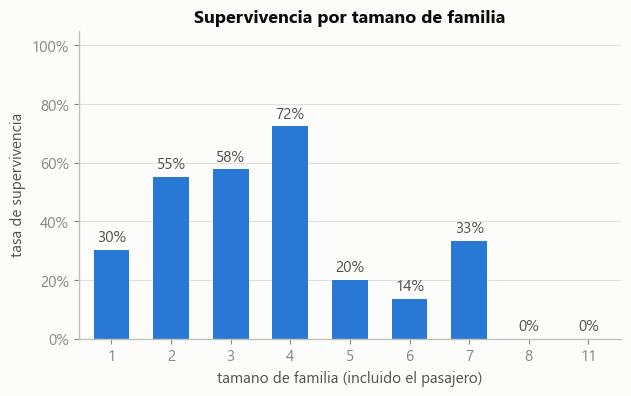

             count   mean
IsAlone                  
Con familia    354  0.506
Viaja solo     537  0.304


In [15]:
fam = train.copy()
fam["FamilySize"] = fam["SibSp"] + fam["Parch"] + 1

tabla_fam = fam.groupby("FamilySize")["Survived"].agg(["count", "mean"]).round(3)
tabla_fam.columns = ["pasajeros", "tasa_supervivencia"]
print(tabla_fam)

tasa_barras(tabla_fam["tasa_supervivencia"], "Supervivencia por tamano de familia", xlabel="tamano de familia (incluido el pasajero)")
plt.show()

solo = fam.assign(IsAlone=(fam["FamilySize"] == 1).map({True: "Viaja solo", False: "Con familia"}))
print(solo.groupby("IsAlone")["Survived"].agg(["count", "mean"]).round(3))

**Interpretación:** la relación tiene forma de **U invertida**, no es lineal:

- Solos (FamilySize=1): ~30%.
- Familias de **2 a 4**: la zona dulce, ~55-72%.
- 5 o más: se desploma (las familias grandes de 3ª clase, muchas con apellidos conocidos como los
  Sage o los Andersson, murieron casi al completo).

Esto justifica crear en la Fase 3 tanto `FamilySize` como agrupaciones tipo *solo / familia pequeña /
familia grande* — a un modelo lineal le costaría capturar una U invertida desde `SibSp` y `Parch`
en crudo.

## 12 · `Cabin` — cuando la ausencia informa

Con 77% de nulos no podemos usar el camarote en sí. Pero probemos la hipótesis de que **que el
camarote esté registrado** ya dice algo: los registros de camarote se conservaron sobre todo para
pasajeros de 1ª clase (y algunos registros se recuperaron de cuerpos/supervivientes).

`notna()` es lo contrario de `isna()`: True si el valor existe.

In [16]:
cab = train.assign(HasCabin=train["Cabin"].notna().map({True: "Con camarote", False: "Sin camarote"}))
print(cab.groupby("HasCabin")["Survived"].agg(["count", "mean"]).round(3), "\n")
print("Proporcion con camarote registrado, por clase:")
print(train.assign(HasCabin=train["Cabin"].notna()).groupby("Pclass")["HasCabin"].mean().round(3))

              count   mean
HasCabin                  
Con camarote    204  0.667
Sin camarote    687  0.300 

Proporcion con camarote registrado, por clase:
Pclass
1    0.815
2    0.087
3    0.024
Name: HasCabin, dtype: float64


**Interpretación:** con camarote registrado → **67%** de supervivencia; sin él → **30%**.
Señal fuerte… pero de nuevo confundida con la clase: el 90% de los pasajeros con camarote son de 1ª.
Aun así, `HasCabin` es gratis de calcular y algo aporta → a la Fase 3.

## 13 · `Name` → `Title`: la joya escondida

Mira un nombre cualquiera: `Braund, Mr. Owen Harris`. El formato es siempre
`Apellido, Título. Nombre`. Ese **título** comprime tres informaciones a la vez:

- **Sexo** (Mr vs Mrs/Miss),
- **Edad aproximada** (`Master` = niño varón; `Miss` = mujer soltera, tendencialmente joven),
- **Estatus** (Dr, Rev, Sir, Countess…).

Lo extraemos con una **expresión regular** (regex): `" ([A-Za-z]+)\."` significa *"un espacio,
luego una o más letras (capturadas), luego un punto"* — exactamente el patrón del título.
Los títulos raros (menos de 10 personas) los agruparemos en una categoría `Rare` para que el modelo
no aprenda de 2 ejemplos.

Titulos encontrados:
 Name
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64 

        pasajeros  tasa_supervivencia
Title                                
Mr            517               0.157
Mrs           125               0.792
Miss          182               0.698
Master         40               0.575
Rare           27               0.444


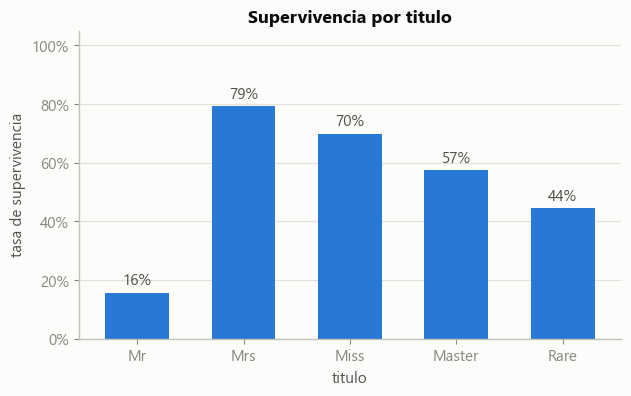

In [17]:
titulos = train["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
print("Titulos encontrados:\n", titulos.value_counts(), "\n")

frecuentes = ["Mr", "Mrs", "Miss", "Master"]
titulos_agrup = titulos.where(titulos.isin(frecuentes), "Rare")

tabla_titulo = train.assign(Title=titulos_agrup).groupby("Title")["Survived"].agg(["count", "mean"]).round(3)
tabla_titulo = tabla_titulo.loc[["Mr", "Mrs", "Miss", "Master", "Rare"]]
tabla_titulo.columns = ["pasajeros", "tasa_supervivencia"]
print(tabla_titulo)

tasa_barras(tabla_titulo["tasa_supervivencia"], "Supervivencia por titulo", xlabel="titulo")
plt.show()

**Interpretación:**

- `Mr` ≈ **16%** vs `Mrs` ≈ 79% / `Miss` ≈ 70% — replica la señal de sexo, como esperábamos.
- Lo valioso: **`Master` ≈ 58%** — son niños varones. Sin el título, un modelo vería "hombre → 19%";
  con él, distingue a los niños. Y funciona **incluso cuando `Age` es nulo**.
- Bonus para la Fase 2: la mediana de edad de cada título (`Master` ≈ 3.5 años, `Mr` ≈ 30…) será
  nuestra base para imputar `Age` con sentido.

## 14 · `Ticket` — los grupos de viaje

Último hilo del que tirar: los billetes compartidos. `groupby("Ticket").transform("count")` cuenta,
para cada pasajero, cuántas personas comparten su billete (dentro de train; en la Fase 3 lo
calcularemos sobre train+test juntos, que es lo correcto para esta feature porque no usa el target).

Esto captura grupos que `FamilySize` no ve: amigos, criados, niñeras… gente que viajaba junta sin
ser familia.

    pasajeros  tasa_supervivencia
1         547               0.298
2         188               0.574
3          63               0.698
4          44               0.500
5+         49               0.102


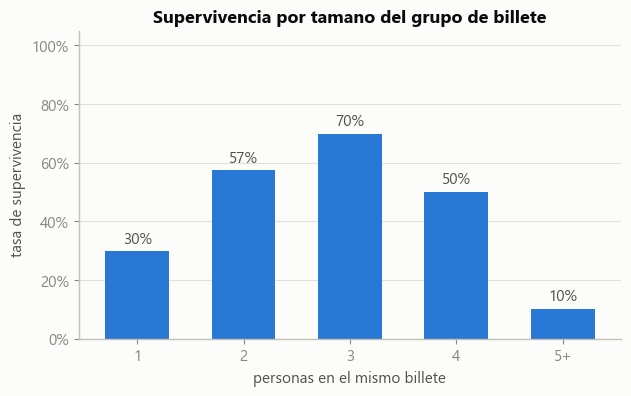

In [18]:
tam_grupo = train.groupby("Ticket")["PassengerId"].transform("count")
tabla_ticket = train.assign(TicketGroup=tam_grupo.clip(upper=5)).groupby("TicketGroup")["Survived"].agg(["count", "mean"]).round(3)
tabla_ticket.columns = ["pasajeros", "tasa_supervivencia"]
tabla_ticket.index = ["1", "2", "3", "4", "5+"]
print(tabla_ticket)

tasa_barras(tabla_ticket["tasa_supervivencia"], "Supervivencia por tamano del grupo de billete", xlabel="personas en el mismo billete")
plt.show()

Mismo patrón de U invertida que `FamilySize` (grupos de 2-4 ≈ 50-70%, solos y grupos grandes
peor), pero calculado desde otra fuente. Además nos permitirá `FarePerPerson = Fare / TicketGroup`.

## 15 · Matriz de correlaciones

La **correlación de Pearson** mide la relación *lineal* entre dos variables numéricas, de **-1**
(cuando una sube la otra baja) a **+1** (suben juntas), con 0 = sin relación lineal.

Preparación: `Sex` es texto, así que la convertimos a número (`female=1, male=0`) para incluirla.
Añadimos también las derivadas que ya exploramos (`FamilySize`, `HasCabin`).

Dos advertencias honestas sobre esta herramienta:

- Solo captura relaciones **lineales y monótonas** — la U invertida de `FamilySize` queda mal
  representada (por eso su correlación saldrá débil aunque vimos que informa).
- Con variables 0/1 es una aproximación (técnicamente, correlación *punto-biserial*), válida para
  ordenar señales pero no para interpretarla al milímetro.

En el mapa de calor usamos una escala **divergente** (rojo = negativo, gris = cero, azul = positivo):
el color codifica el signo y la intensidad a la vez.

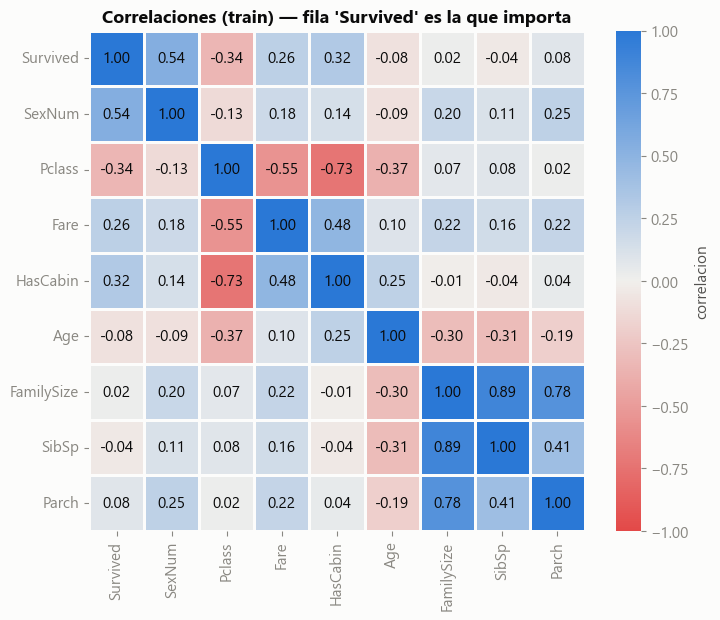

In [19]:
from matplotlib.colors import LinearSegmentedColormap

corr_df = train.assign(
    SexNum=(train["Sex"] == "female").astype(int),
    FamilySize=train["SibSp"] + train["Parch"] + 1,
    HasCabin=train["Cabin"].notna().astype(int),
)[["Survived", "SexNum", "Pclass", "Fare", "HasCabin", "Age", "FamilySize", "SibSp", "Parch"]]

corr = corr_df.corr().round(2)

CMAP_DIV = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=CMAP_DIV, vmin=-1, vmax=1,
            linewidths=2, linecolor=SURFACE, cbar_kws={"label": "correlacion"},
            annot_kws={"color": INK}, ax=ax)
ax.set_title("Correlaciones (train) — fila 'Survived' es la que importa")
ax.grid(visible=False)
plt.show()

**Lectura de la fila `Survived`:**

| Variable | corr | Comentario |
|---|---|---|
| `SexNum` (mujer=1) | **+0.54** | La reina, como ya sabíamos. |
| `Pclass` | **-0.34** | Negativa: clase "mayor" (3ª) → menos supervivencia. |
| `Fare` | +0.26 | Positiva, en parte redundante con Pclass (corr Fare-Pclass = -0.55). |
| `HasCabin` | +0.32 | Fuerte, confundida con clase (corr con Pclass = -0.73). |
| `Age` | -0.08 | ¡Casi cero! Pero sabemos que **sí** informa (niños): la señal no es lineal, y Pearson no la ve. Lección: correlación baja ≠ variable inútil. |
| `FamilySize` | +0.02 | Ídem: la U invertida se anula a sí misma en una medida lineal. |

También vemos redundancias entre features (Fare↔Pclass, HasCabin↔Pclass): no pasa nada grave, pero
explica por qué añadir `HasCabin` aporta menos de lo que su correlación con `Survived` sugiere.

## 16 · Conclusiones del EDA

Lo que nos llevamos, ordenado por lo que implica para cada fase:

**Señales encontradas (de más a menos fuertes):**
1. `Sex` — 74% mujeres vs 19% hombres. Baseline de género: 0.7655.
2. `Pclass` — 63% / 47% / 24%. Interacción clave con sexo: mujeres 1ª-2ª casi todas viven; el punto de incertidumbre está en mujeres de 3ª y hombres de 1ª.
3. `Title` (de `Name`) — replica sexo Y añade a los niños (`Master` 58%) y estatus. Funciona con `Age` nulo.
4. Edad — solo discrimina en los niños (0-10 ≈ 59%). Relación NO lineal.
5. `Fare` / `HasCabin` — señal real pero muy solapada con `Pclass`.
6. `FamilySize` / grupo de ticket — U invertida: 2-4 bien, solos y 5+ mal. NO lineal.
7. `Embarked` — señal débil y confundida con clase.

**Para la Fase 2 (limpieza):**
- `Age`: imputar mediana por `Title` (+ `Pclass`). `Embarked`: moda. `Fare` (test): mediana de su clase. `Cabin`: solo derivar `HasCabin`.
- Todo dentro de un pipeline que aprenda SOLO de train.

**Para la Fase 3 (features):**
- `Title` (Mr/Mrs/Miss/Master/Rare), `FamilySize` + agrupación (solo/pequeña/grande), `TicketGroup` y `FarePerPerson`, `HasCabin`. Codificar categóricas con one-hot.

**Para la Fase 5 (modelos):**
- Hay al menos dos relaciones no lineales (edad, familia) y una interacción fuerte (sexo × clase) →
  los modelos de **árboles** (Random Forest, Gradient Boosting) parten con ventaja sobre la regresión
  logística pura; la logística servirá de baseline.